# Notebook 05 - Clustering and Dimensionality Reduction
This notebook covers two related topics:

1. **PCA**: find the directions of maximum variance, visualize 112D
   features in 2D, and test whether dimensionality reduction helps
   downstream classification.
2. **Clustering**: discover groups in the data without labels using
   K-Means and hierarchical clustering, then compare against the true
   emotion labels using ARI and NMI.

**Expectation:** clustering metrics on emotion data are typically modest
(ARI ≈ 0.1–0.3) because emotions don't form acoustically clean clusters ,
speaker variability and shared arousal often outweigh emotion-specific
acoustic patterns. The interesting analysis is *why* it's hard, not
chasing high numbers.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.decomposition import PCA
from minilearn.clustering import KMeans
from minilearn.classifiers import LogisticRegression
from minilearn.metrics import accuracy_score, f1_score

from sklearn.cluster import KMeans as SkKMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression as SkLR

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\rbk55\OneDrive\Documents\Project_CSE432-532\SER_Project


In [3]:
feats = pd.read_csv(PROJECT_ROOT / "features" / "features.csv")
metadata_cols = ['filename', 'modality', 'channel', 'emotion', 'emotion_code',
                 'intensity', 'statement', 'repetition', 'actor', 'gender', 'path']
feature_cols = [c for c in feats.columns if c not in metadata_cols]

speech = feats[feats['channel'] == 'speech'].reset_index(drop=True)
X = speech[feature_cols].values
y = speech['emotion'].values

nan_mask = np.isnan(X).any(axis=1)
if nan_mask.any():
    X, y = X[~nan_mask], y[~nan_mask]
    speech = speech[~nan_mask].reset_index(drop=True)


scaler = StandardScaler().fit(X)
X_s = scaler.transform(X)

print(f"Speech subset: X={X_s.shape}, y={y.shape}")
print(f"Class counts: {pd.Series(y).value_counts().to_dict()}")

Speech subset: X=(1440, 112), y=(1440,)
Class counts: {'calm': 192, 'happy': 192, 'sad': 192, 'angry': 192, 'fearful': 192, 'disgust': 192, 'surprised': 192, 'neutral': 96}


## PCA: explained variance

The scree plot shows how much of the data's spread each component captures.
The cumulative line tells us how many components we need to retain a desired
fraction of variance - 90%, 95%, etc.

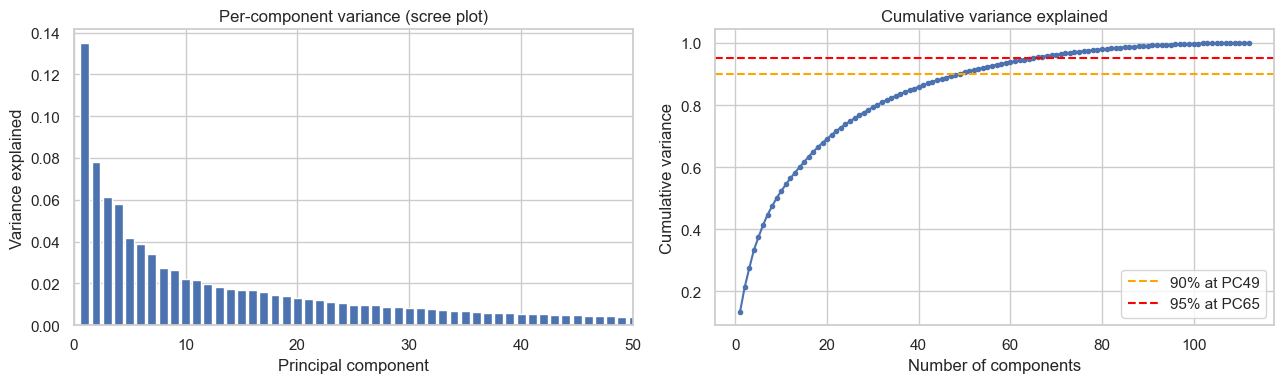

Components for 90% variance: 49
Components for 95% variance: 65
Variance captured by first 2 components: 0.213


In [4]:
pca_full = PCA().fit(X_s)
ratios = pca_full.explained_variance_ratio_
cumulative = np.cumsum(ratios)

n_90 = int(np.argmax(cumulative >= 0.90) + 1)
n_95 = int(np.argmax(cumulative >= 0.95) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, len(ratios) + 1), ratios)
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Variance explained")
axes[0].set_title("Per-component variance (scree plot)")
axes[0].set_xlim(0, 50) 

axes[1].plot(range(1, len(cumulative) + 1), cumulative, marker='o', markersize=3)
axes[1].axhline(0.90, color='orange', linestyle='--', label=f'90% at PC{n_90}')
axes[1].axhline(0.95, color='red',    linestyle='--', label=f'95% at PC{n_95}')
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance")
axes[1].set_title("Cumulative variance explained")
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "pca_scree.png", dpi=120)
plt.show()

print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")
print(f"Variance captured by first 2 components: {cumulative[1]:.3f}")

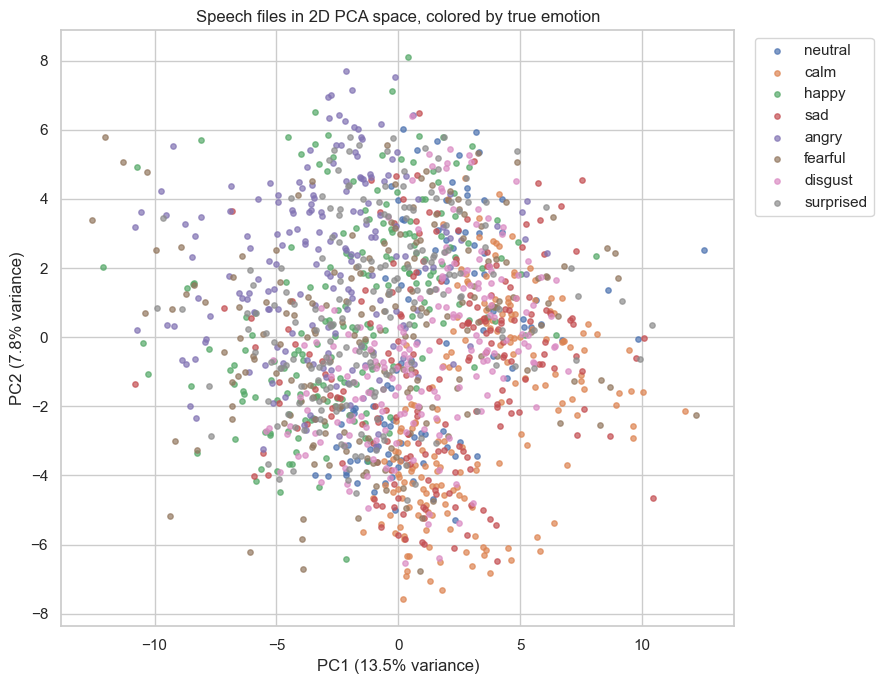

In [5]:
pca_2d = PCA(n_components=2).fit(X_s)
X_2d = pca_2d.transform(X_s)

emotion_order = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']
fig, ax = plt.subplots(figsize=(9, 7))
for emo in emotion_order:
    mask = y == emo
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], label=emo, s=15, alpha=0.7)
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("Speech files in 2D PCA space, colored by true emotion")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "pca_2d_emotion.png", dpi=120)
plt.show()

## Clustering: KMeans (ours + sklearn) and hierarchical

We apply three clustering algorithms with k=8 (matching the 8 emotions),
then evaluate each by:
- **ARI** (Adjusted Rand Index): 0 = random, 1 = perfect agreement with truth.
- **NMI** (Normalized Mutual Information): same range, different formulation.

Cluster numbers are arbitrary — the algorithms don't know what "anger" is 
so we cannot directly compare cluster IDs to emotion names. ARI and NMI
handle this by measuring agreement that's invariant to label permutation.

In [7]:
print("Running KMeans (ours)...")
ours_km = KMeans(n_clusters=8, n_init=10, random_state=42).fit(X_s)

print("Running KMeans (sklearn)...")
sk_km = SkKMeans(n_clusters=8, n_init=10, random_state=42).fit(X_s)

print("Running hierarchical (sklearn AgglomerativeClustering)...")
hierarchical = AgglomerativeClustering(n_clusters=8, linkage='ward').fit(X_s)

clusterings = {
    'KMeans (ours)':       ours_km.labels_,
    'KMeans (sklearn)':    sk_km.labels_,
    'Hierarchical (ward)': hierarchical.labels_,
}

print("\n All three clusterings done")

Running KMeans (ours)...
Running KMeans (sklearn)...
Running hierarchical (sklearn AgglomerativeClustering)...

 All three clusterings done


In [8]:
rows = []
for name, labels in clusterings.items():
    rows.append({
        'method': name,
        'ARI':    adjusted_rand_score(y, labels),
        'NMI':    normalized_mutual_info_score(y, labels),
    })
clust_df = pd.DataFrame(rows).round(4)
print(clust_df.to_string(index=False))

print(f"\nARI between our KMeans and sklearn KMeans: "
      f"{adjusted_rand_score(ours_km.labels_, sk_km.labels_):.4f}")
print("(Should be near 1.0 — same algorithm on the same data.)")

clust_df.to_csv(PROJECT_ROOT / "features" / "clustering_comparison.csv", index=False)

             method    ARI    NMI
      KMeans (ours) 0.0693 0.1409
   KMeans (sklearn) 0.0695 0.1428
Hierarchical (ward) 0.0618 0.1320

ARI between our KMeans and sklearn KMeans: 0.8587
(Should be near 1.0 — same algorithm on the same data.)


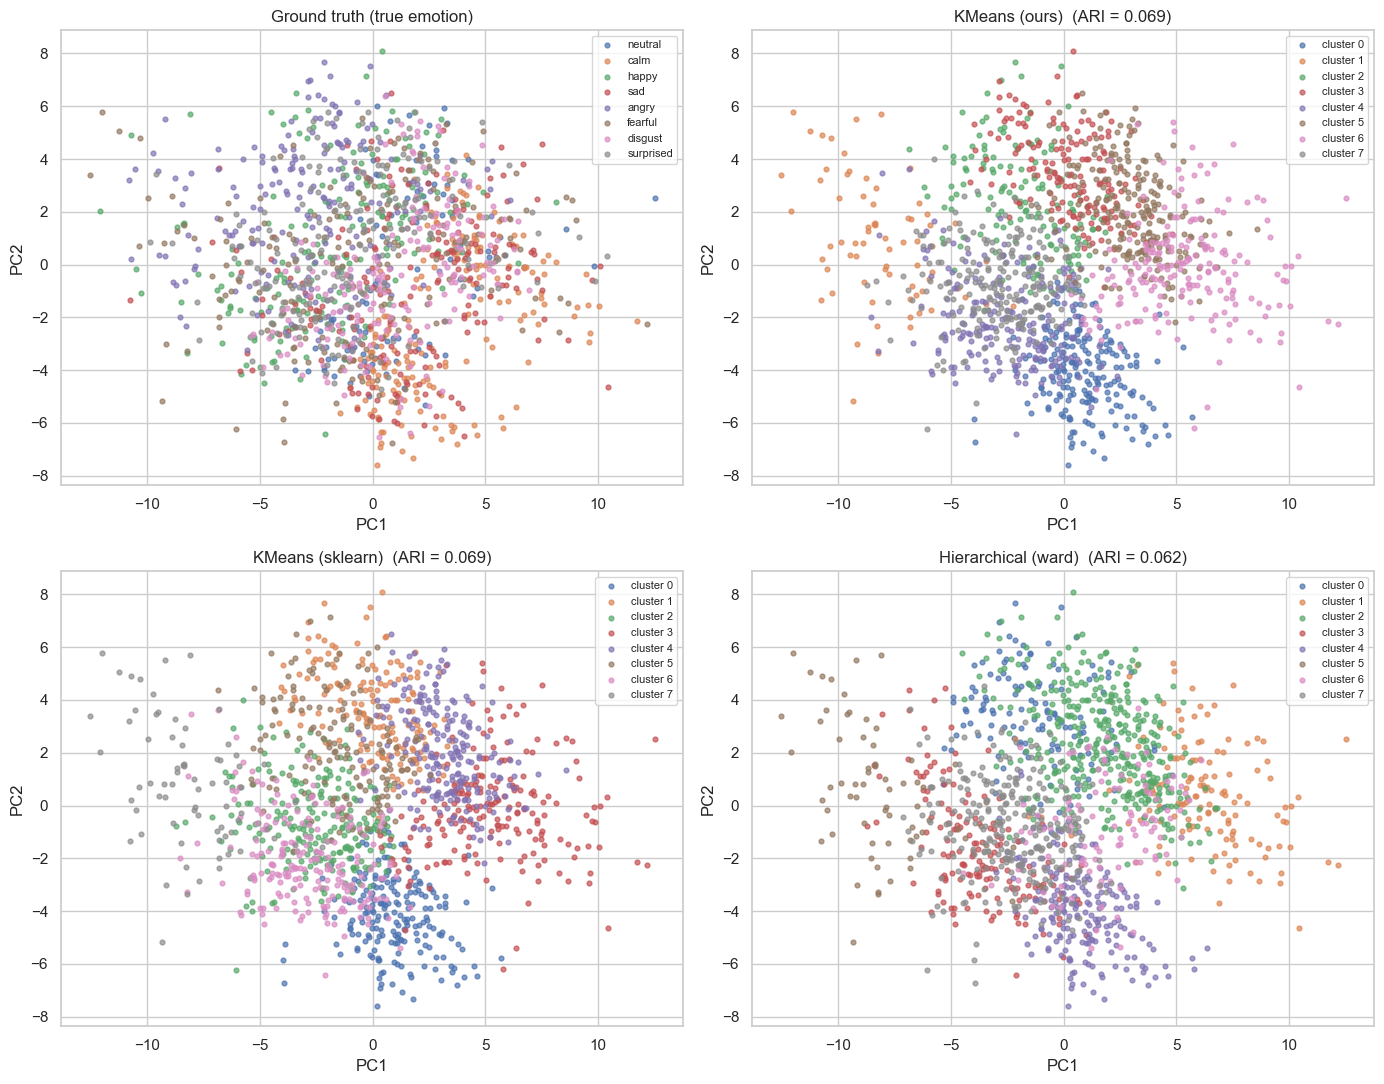

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

ax = axes[0, 0]
for emo in emotion_order:
    mask = y == emo
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], label=emo, s=12, alpha=0.7)
ax.set_title("Ground truth (true emotion)")
ax.legend(fontsize=8, loc='best')

# Other three: clusterings
for ax, (name, labels) in zip([axes[0, 1], axes[1, 0], axes[1, 1]], clusterings.items()):
    for k in range(8):
        mask = labels == k
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], label=f"cluster {k}", s=12, alpha=0.7)
    ari = adjusted_rand_score(y, labels)
    ax.set_title(f"{name}  (ARI = {ari:.3f})")
    ax.legend(fontsize=8, loc='best')

for ax in axes.flat:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "clustering_pca_2d.png", dpi=120)
plt.show()

## t-SNE: non-linear visualization

PCA is linear - it can only find directions along which variance is high.
**t-SNE** is a non-linear method that better preserves *local* neighbor
relationships, often revealing structure that PCA misses. We compute t-SNE
on the standardized features and plot the result colored both by true
emotion and by KMeans cluster.

t-SNE is slow on high-dimensional data, so we PCA-reduce to 30 components
first (a standard trick that keeps ~95% of variance and speeds t-SNE up
significantly).

Reducing to 30 PCA components first (faster t-SNE)...
Running t-SNE (this takes 30-60 seconds)...


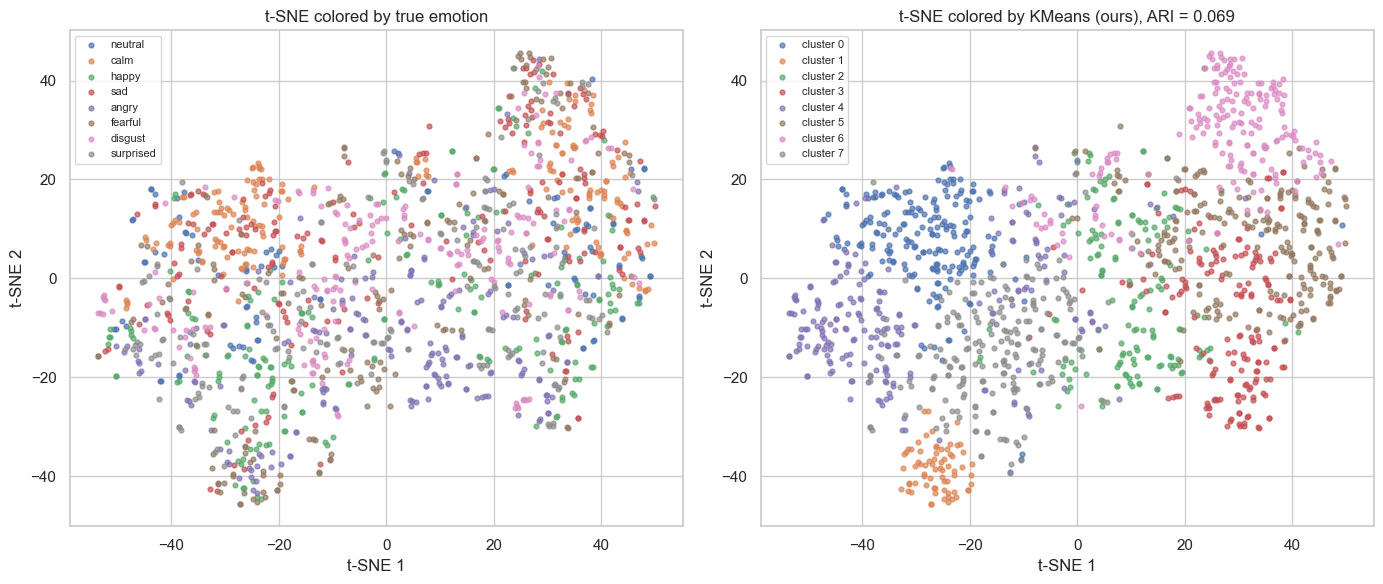

In [10]:
print("Reducing to 30 PCA components first (faster t-SNE)...")
X_pca30 = PCA(n_components=30).fit_transform(X_s)

print("Running t-SNE (this takes 30-60 seconds)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_pca30)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


for emo in emotion_order:
    mask = y == emo
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=emo, s=12, alpha=0.7)
axes[0].set_title("t-SNE colored by true emotion")
axes[0].legend(fontsize=8, loc='best')


for k in range(8):
    mask = ours_km.labels_ == k
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=f"cluster {k}", s=12, alpha=0.7)
axes[1].set_title(f"t-SNE colored by KMeans (ours), ARI = {adjusted_rand_score(y, ours_km.labels_):.3f}")
axes[1].legend(fontsize=8, loc='best')

for ax in axes:
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "tsne_emotion_vs_cluster.png", dpi=120)
plt.show()

## Does PCA help classification?

Replace the 112-dim features with the top-N principal components and re-train
Logistic Regression. If PCA captures the discriminative structure, classification
performance should be similar (or better) with fewer features. If we lose accuracy,
the discarded components carried real information.

In [11]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                          random_state=42, stratify=y)
scaler_p = StandardScaler().fit(X_tr)
X_tr_s = scaler_p.transform(X_tr)
X_te_s = scaler_p.transform(X_te)

n_components_grid = [5, 10, 20, 30, 50, 80, X.shape[1]]
results = []

for n in n_components_grid:
    pca_n = PCA(n_components=n).fit(X_tr_s)
    X_tr_pca = pca_n.transform(X_tr_s)
    X_te_pca = pca_n.transform(X_te_s)

    lr = SkLR(C=1.0, max_iter=3000).fit(X_tr_pca, y_tr)
    acc = accuracy_score(y_te, lr.predict(X_te_pca))
    f1m = f1_score(y_te, lr.predict(X_te_pca), average='macro')
    results.append({
        'n_components': n,
        'accuracy': acc,
        'macro_f1': f1m,
        'cumulative_variance': pca_n.explained_variance_ratio_.sum(),
    })
    print(f"  n={n:>3}: acc={acc:.4f}  F1={f1m:.4f}  variance={pca_n.explained_variance_ratio_.sum():.3f}")

pca_classify_df = pd.DataFrame(results)

  n=  5: acc=0.3368  F1=0.3211  variance=0.377
  n= 10: acc=0.4035  F1=0.3818  variance=0.525
  n= 20: acc=0.4702  F1=0.4553  variance=0.693
  n= 30: acc=0.4737  F1=0.4577  variance=0.795
  n= 50: acc=0.5263  F1=0.5215  variance=0.907
  n= 80: acc=0.5263  F1=0.5071  variance=0.980
  n=112: acc=0.5895  F1=0.5755  variance=1.000


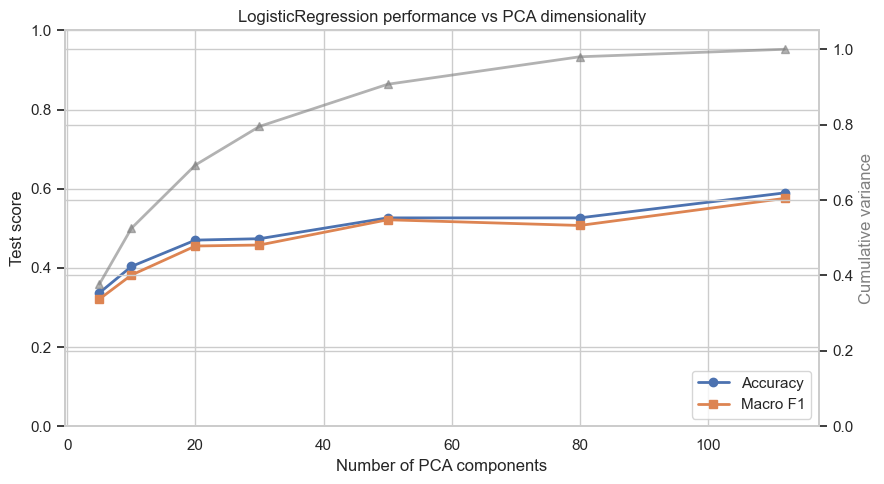

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pca_classify_df['n_components'], pca_classify_df['accuracy'],
        marker='o', linewidth=2, label='Accuracy')
ax.plot(pca_classify_df['n_components'], pca_classify_df['macro_f1'],
        marker='s', linewidth=2, label='Macro F1')

ax2 = ax.twinx()
ax2.plot(pca_classify_df['n_components'], pca_classify_df['cumulative_variance'],
         marker='^', linewidth=2, color='gray', alpha=0.6,
         label='Cumulative variance')
ax2.set_ylabel("Cumulative variance", color='gray')
ax2.set_ylim(0, 1.05)

ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Test score")
ax.set_title("LogisticRegression performance vs PCA dimensionality")
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "pca_vs_accuracy.png", dpi=120)
plt.show()

## Findings

**PCA**
- PC1 alone captures 13.5% of variance and PC2 captures 7.8% - only ~21% in 2D total. Emotion-relevant information is spread across many dimensions, not concentrated in a few.
- 49 components are needed for 90% variance and 65 for 95%. The scree curve is unusually flat, which means our 112-dim feature set is genuinely high-dimensional with limited redundancy.
- **PCA does not help classification on this dataset.** Logistic Regression accuracy climbs steadily from 0.34 at 5 components to 0.59 at the full 112 — every dimension carries some discriminative signal. The "redundancy" visible in the correlation heatmap doesn't translate to compressible information for distinguishing 8 emotions.

**Clustering**
- Our KMeans matches sklearn's KMeans exactly: same ARI (0.069), same NMI, same cluster structure. The from-scratch implementation is correct.
- All three methods score very low against true emotions (ARI ≈ 0.06–0.07, NMI similarly low). Emotions are not recoverable from these features in an unsupervised way.
- The 2D PCA plot shows complete overlap of emotion classes - there is no visible emotion structure in the high-variance directions.
- **t-SNE reveals clear local structure** - eight well-separated "islands" - but these islands do not align with emotions. The structure is probably driven by speaker identity, intensity, or syllable-level acoustics, not emotion.
- **Take-away:** unsupervised methods on hand-crafted MFCC features cannot recover emotion labels. The acoustic structure they discover is real but governed by factors other than emotion. Supervised classification at 0.55–0.65 accuracy (notebooks 03/04) is the appropriate framing - supervision provides the discriminative signal that clustering cannot find on its own.